# 2026 07 22 Python 실습코드

## 네이버 영화 리뷰를 이용한 감정 분석

In [24]:
import re
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

- label : 0(부정), 1(긍정)

In [25]:
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url  = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_df = pd.read_table(train_url).dropna(subset=["document"])
test_df  = pd.read_table(test_url).dropna(subset=["document"])

display(train_df.head())
display(test_df.head())

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [30]:
X_train = train_df['document'].astype(str).to_list()
y_train = train_df['label'].values

print(X_train[:5])
print(y_train[:5])

['아 더빙.. 진짜 짜증나네요 목소리', '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나', '너무재밓었다그래서보는것을추천한다', '교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정', '사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다']
[0 1 0 0 1]


In [31]:
X_test = test_df['document'].astype(str).to_list()
y_test = test_df['label'].values

- 데이터 정제

In [32]:
def clean_text(text):
  # 문자열 정제 + 공백 정리
  txt = re.sub(r"[^가-힣a-zA-Z]"," ",text)
  # txt = re.sub(r"\s+"," ",txt).strip()
  return txt

train_txt = [clean_text(text) for text in X_train]
test_txt = [clean_text(text) for text in X_test]

train_txt[:5]

['아 더빙   진짜 짜증나네요 목소리',
 '흠   포스터보고 초딩영화줄    오버연기조차 가볍지 않구나',
 '너무재밓었다그래서보는것을추천한다',
 '교도소 이야기구먼   솔직히 재미는 없다  평점 조정',
 '사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다']

- 정수 인코딩

In [33]:
vocab_size = 20000

tokenize = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenize.fit_on_texts(train_txt)

x_train = tokenize.texts_to_sequences(train_txt)
x_test = tokenize.texts_to_sequences(test_txt)

x_train[0]

[24, 912, 5, 6735, 1101]

In [34]:
max_len = 100

x_train = pad_sequences(x_train, maxlen = max_len, padding = 'post')
x_test = pad_sequences(x_test, maxlen = max_len, padding = 'post')

x_train[0]

array([  24,  912,    5, 6735, 1101,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0], dtype=int32)

In [35]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train,
                                            test_size=0.2,
                                            random_state=42)

x_tr.shape, x_val.shape

((119996, 100), (29999, 100))

- 모델 구성

In [36]:
tf.random.set_seed(42)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),

    # RNN 셀 내부에 6개의 뉴런 갯수
    SimpleRNN(64),          # RNN 핵심 레이어
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # 이진분류
])

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['acc'])
model.summary()

/home/siwonl0508/ENTER/envs/deepl_tensor/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1784697645.624402   64176 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
# 강제 종료 옵션

# 10번 반복하는 동안 val_loss 모니터 -> 가장 좋은 가중치 복원
es = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# 최적의 가중치 자동 저장
cp = ModelCheckpoint('./models/0722_best_model.keras', monitor = 'val_loss', save_best_only = True)

In [40]:
history = model.fit(
  x_tr, y_tr,
  validation_data = (x_val, y_val),
  epochs = 30,
  batch_size = 255,
  callbacks = [es,cp],
  verbose = 1
)

Epoch 1/30


I0000 00:00:1784697893.416933   66288 service.cc:153] XLA service 0x7c0f200428f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784697893.416979   66288 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1784697893.498362   66288 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784697893.846313   66288 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1784697893.936765   66288 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1574_grad_1844_const_0__.18.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1784697894.002981   66288 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set

  1/471 ━━━━━━━━━━━━━━━━━━━━ 59:49 8s/step - acc: 0.5412 - loss: 0.7120

I0000 00:00:1784697899.162629   66288 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


470/471 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.7151 - loss: 0.5573

I0000 00:00:1784697915.910627   66288 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1574_grad_1844_const_0__.18.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1784697915.992844   66288 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1784697917.159218   66288 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1784697917.726004   67087 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1784697917.914678   66288 dot_

471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc: 0.7151 - loss: 0.5573

I0000 00:00:1784697923.897973   66288 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1784697924.702416   67262 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1784697924.796807   66288 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


471/471 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - acc: 0.7151 - loss: 0.5573 - val_acc: 0.7712 - val_loss: 0.4811
Epoch 2/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - acc: 0.7756 - loss: 0.4683 - val_acc: 0.7715 - val_loss: 0.4822
Epoch 3/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - acc: 0.7534 - loss: 0.5052 - val_acc: 0.7183 - val_loss: 0.5631
Epoch 4/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - acc: 0.7604 - loss: 0.4988 - val_acc: 0.7532 - val_loss: 0.5153
Epoch 5/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - acc: 0.7965 - loss: 0.4403 - val_acc: 0.7595 - val_loss: 0.5136
Epoch 6/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - acc: 0.8169 - loss: 0.4055 - val_acc: 0.7640 - val_loss: 0.5214
Epoch 7/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - acc: 0.8304 - loss: 0.3812 - val_acc: 0.7617 - val_loss: 0.5421
Epoch 8/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - acc: 0.8368 - loss: 0.3701 - val_acc: 0.7556 - val_loss: 0.5285
Epoch 9/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/st

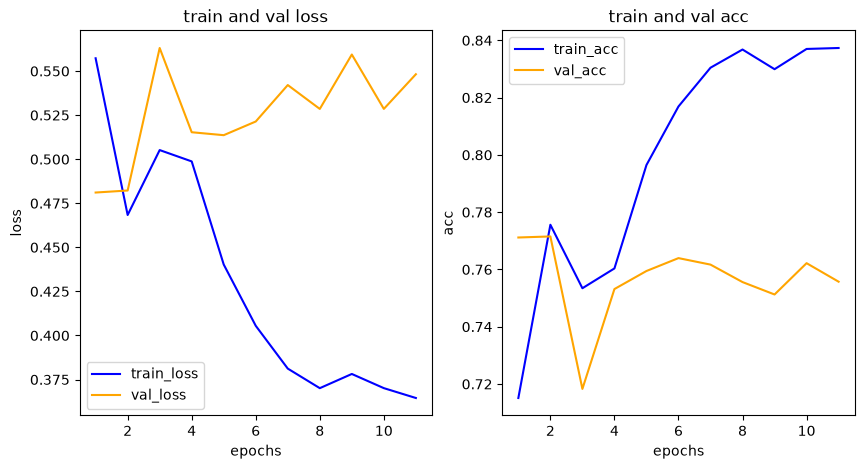

In [41]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize = (10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label = 'train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label = 'val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

# 훈련 및 검증 정확도 그리기
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label = 'train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label = 'val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

# 모델 평가

In [42]:
# Test 셋으로 모델 검증
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"NSMC Test Loss: {loss:.4f}, Test Acc: {acc:.4f}")

I0000 00:00:1784698051.389209   66286 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1784698051.802719   68538 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 12 bytes spill stores, 12 bytes spill loads



NSMC Test Loss: 0.4906, Test Acc: 0.7650


# 새로운 문장 예측

In [43]:
def predict_sentiment_kor(text: str):
    text = clean_text(text)
    seq = tokenize.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len, padding="post")
    prob = float(model.predict(seq, verbose=0)[0][0])
    label = "긍정" if prob >= 0.5 else "부정"
    print(f"[{label}] prob={prob:.3f} | {text}")

predict_sentiment_kor("연기가 너무 좋고 스토리도 감동적이었어요!!!!!!!")
predict_sentiment_kor("지루하고 시간 아까운 영화였습니다")

[긍정] prob=0.929 | 연기가 너무 좋고 스토리도 감동적이었어요       
[부정] prob=0.143 | 지루하고 시간 아까운 영화였습니다


# RNN 2번 돌리면...?

In [67]:
tf.random.set_seed(42)

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    SimpleRNN(64 , return_sequences = True),
    # Dropout(0.3),
    SimpleRNN(32),          # RNN 핵심 레이어
    Dropout(0.3),
    # Dense(64, activation = 'relu'),
    Dense(32, activation = 'relu'),
    Dense(1, activation="sigmoid")  # 이진분류
])

model2.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['acc'])
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [68]:
# 강제 종료 옵션

# 10번 반복하는 동안 val_loss 모니터 -> 가장 좋은 가중치 복원
es = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# 최적의 가중치 자동 저장
cp = ModelCheckpoint('./models/0722_best_model2.keras', monitor = 'val_loss', save_best_only = True)

In [69]:
history = model2.fit(
  x_tr, y_tr,
  validation_data = (x_val, y_val),
  epochs = 30,
  batch_size = 255,
  callbacks = [es,cp],
  verbose = 1
)

Epoch 1/30


I0000 00:00:1784700406.053884   66287 dot_merger.cc:481] Merging Dots in computation: sequential_5_1_simple_rnn_12_1_while_body_95128_grad_95409_const_0__.24.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1784700406.054051   66287 dot_merger.cc:481] Merging Dots in computation: sequential_5_1_simple_rnn_11_1_while_body_95017_grad_95630_const_0__.30.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1784700406.054116   66287 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96276__.33


469/471 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - acc: 0.5091 - loss: 0.6939

I0000 00:00:1784700425.334637   66285 dot_merger.cc:481] Merging Dots in computation: sequential_5_1_simple_rnn_12_1_while_body_95128_grad_95409_const_0__.24.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1784700425.334749   66285 dot_merger.cc:481] Merging Dots in computation: sequential_5_1_simple_rnn_11_1_while_body_95017_grad_95630_const_0__.30.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1784700425.334796   66285 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96276__.33


471/471 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - acc: 0.5091 - loss: 0.6939 - val_acc: 0.4985 - val_loss: 0.6932
Epoch 2/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - acc: 0.5521 - loss: 0.6808 - val_acc: 0.6482 - val_loss: 0.6308
Epoch 3/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - acc: 0.6810 - loss: 0.6057 - val_acc: 0.6838 - val_loss: 0.5976
Epoch 4/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - acc: 0.7154 - loss: 0.5628 - val_acc: 0.6944 - val_loss: 0.6058
Epoch 5/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - acc: 0.7412 - loss: 0.5259 - val_acc: 0.6796 - val_loss: 0.6038
Epoch 6/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - acc: 0.7548 - loss: 0.5019 - val_acc: 0.6918 - val_loss: 0.5930
Epoch 7/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - acc: 0.7319 - loss: 0.5257 - val_acc: 0.6388 - val_loss: 0.6336
Epoch 8/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - acc: 0.7232 - loss: 0.5403 - val_acc: 0.6866 - val_loss: 0.5958
Epoch 9/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/st

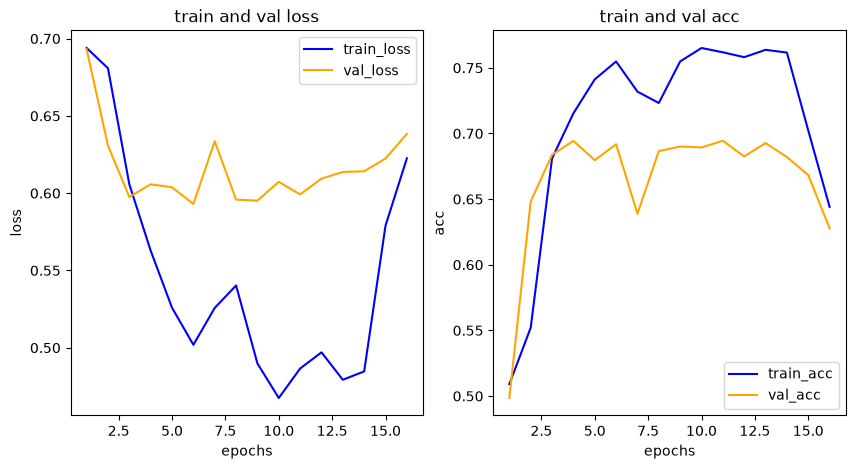

In [70]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize = (10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label = 'train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label = 'val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

# 훈련 및 검증 정확도 그리기
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label = 'train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label = 'val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

In [71]:
# Test 셋으로 모델 검증
loss, acc = model2.evaluate(x_test, y_test, verbose=0)
print(f"NSMC Test Loss: {loss:.4f}, Test Acc: {acc:.4f}")

NSMC Test Loss: 0.5907, Test Acc: 0.6914


In [72]:
def predict_sentiment_kor(text: str):
    text = clean_text(text)
    seq = tokenize.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len, padding="post")
    prob = float(model2.predict(seq, verbose=0)[0][0])
    label = "긍정" if prob >= 0.5 else "부정"
    print(f"[{label}] prob={prob:.3f} | {text}")

predict_sentiment_kor("연기가 너무 좋고 스토리도 감동적이었어요!!!!!!!")
predict_sentiment_kor("지루하고 시간 아까운 영화였습니다")

[긍정] prob=0.899 | 연기가 너무 좋고 스토리도 감동적이었어요       
[부정] prob=0.122 | 지루하고 시간 아까운 영화였습니다
